# Create weather station analysis

### Get PROMICE level 3 weather station data

In [ ]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Download hourly level 3 Promice station data as netcdf from https://thredds.geus.dk/thredds/catalog/catalog.html : 
# wget https://thredds.geus.dk/thredds/fileServer/aws/l3sites/netcdf/hour/MIT_hour.nc
# wget https://thredds.geus.dk/thredds/fileServer/aws/l3sites/netcdf/hour/TAS_A_hour.nc
# wget https://thredds.geus.dk/thredds/fileServer/aws/l3sites/netcdf/hour/TAS_L_hour.nc
dir_station_lvl3 = '/Users/bjoern/data/hrmelt/raw/promice_station_data/hour/level3/' #    TAS_A_hour.nc TAS_L_hour.nc

ds_MIT = xr.open_dataset(os.path.join(dir_station_lvl3, 'MIT_hour.nc'))
ds_TAS_A = xr.open_dataset(os.path.join(dir_station_lvl3, 'TAS_A_hour.nc'))
ds_TAS_L = xr.open_dataset(os.path.join(dir_station_lvl3, 'TAS_L_hour.nc'))

In [37]:
# subset data at 6am
timeidx = 7 # Greenland is 1-2hr ahead of UTC 
time_6am = ds_TAS_A['time'].sel(time=ds_TAS_A.time.dt.hour == timeidx)
ds_MIT_6am = ds_MIT.sel(time=ds_MIT.time.dt.hour == timeidx)
ds_TAS_A_6am = ds_TAS_A.sel(time=ds_TAS_A.time.dt.hour == timeidx)
ds_TAS_L_6am = ds_TAS_L.sel(time=ds_TAS_L.time.dt.hour == timeidx)

# convert from 6am timestamp to daily
#  2017-01-01T06:00:00 becomes 2017-01-01T00:00:00
ds_MIT_6am = ds_MIT_6am.assign_coords(time=lambda x: x.time.dt.floor('D'))
ds_TAS_A_6am = ds_TAS_A_6am.assign_coords(time=lambda x: x.time.dt.floor('D'))
ds_TAS_L_6am = ds_TAS_L_6am.assign_coords(time=lambda x: x.time.dt.floor('D'))

# subset to data period
start_time = '2017-01-01'
end_time = '2023-12-31'
ds_MIT_6am = ds_MIT_6am.sel(time=slice(start_time, end_time))
ds_TAS_A_6am = ds_TAS_A_6am.sel(time=slice(start_time, end_time))
ds_TAS_L_6am = ds_TAS_L_6am.sel(time=slice(start_time, end_time))

# Use land surface temperature (t_surf) > -1 threshold to define when melt is present
da_MIT_melt = xr.where(ds_MIT_6am['t_surf'] > -1, 1, 0).where(ds_MIT_6am['t_surf'].notnull())
da_TAS_A_melt = xr.where(ds_TAS_A_6am['t_surf'] > -1, 1, 0).where(ds_TAS_A_6am['t_surf'].notnull())
da_TAS_L_melt = xr.where(ds_TAS_L_6am['t_surf'] > -1, 1, 0).where(ds_TAS_L_6am['t_surf'].notnull())

# Use air temperature (t_u) > 0 threshold to define when melt is present
#  da_MIT_melt = xr.where(ds_MIT_6am['t_u'] > 0, 1, 0).where(ds_MIT_6am['t_u'].notnull())
#  da_TAS_A_melt = xr.where(ds_TAS_A_6am['t_u'] > 0, 1, 0).where(ds_TAS_A_6am['t_u'].notnull())
#  da_TAS_L_melt = xr.where(ds_TAS_L_6am['t_u'] > 0, 1, 0).where(ds_TAS_L_6am['t_u'].notnull())

In [38]:
# Patrick reports average station location is:
# MIT 9/1/23 18:00 65.691953 -37.829813
# TAS_A 10/9/23 12:00 65.774442 -38.890758
# TAS_L 5/13/24 21:00 65.63915 -38.899191

# Marco uses the station surface temperature value and assigns melting when it exceeds 0.01ºC. 

# Patrick converted the average station lat/lon to pixel coordinates via Matlab:
# %% Load Geotiff and info.
# [elevation, R] = readgeoraster(geoTiffFile);
# I = geotiffinfo(geoTiffFile);
# [x,y] = pixcenters(I);
# [X,Y] = meshgrid(x,y);
# %% Convert station coordinates.
# lat_mit = 65.691953;
# lon_mit = -37.829813;
# proj = R.ProjectedCRS;
# [x_mit, y_mit] = projfwd(proj,lat_mit,lon_mit);
# dist_mit =   sqrt( (X-x_mit).^2 + (Y-y_mit).^2 );
# [i_mit,  j_mit] = find(dist_mit == min(dist_mit(:)));

# Pixel coordinates of the PROMICE weather stations
coords_stations = {
    # np.array((Offset from top of image in px,
    #   offset from left of image in px))
    "mit": np.array((2067,986)),
    "tas_a": np.array((1987,502)),
    "tas_l": np.array((2140,501))
}

### Compare with predictions

In [39]:
# Load UNet predictions
import glob
from tqdm.notebook import tqdm
from datetime import datetime
import pandas as pd
from pathlib import Path
from osgeo import gdal


# path_deploy_unet_smp = '/home/gridsan/lutjens/EarthIntelligence_shared/datasets/hrmelt/interim/runs/unet_smp/data_v1_4/deploy/'
path_deploy_unet_smp = '/Users/bjoern/data/hrmelt/meltwaterbench/interim/runs/unet_smp/data_v1_4/deploy/'
paths_unet_smp = sorted(list(Path(path_deploy_unet_smp).glob("*.tif")))
paths_unet_smp = sorted(list(Path(path_deploy_unet_smp).glob("*.tif")))

# Open geotiff metadata
# data_root = '/home/gridsan/lutjens/EarthIntelligence_shared/datasets/hrmelt/'
# path_dem = 'raw/Helheim_data/reprojected_100m/GrIMP_DEM/dem_100m.tif'
data_root = '/Users/bjoern/data/hrmelt/meltwaterbench/'
path_dem = 'raw/Helheim_data/reprojected_100m/GrIMP_DEM/dem_100m.tif'
ds = gdal.Open(data_root + path_dem)
img_size = [ds.RasterYSize, ds.RasterXSize] # height, width

station_names = ['mit', 'tas_a', 'tas_l']
years = ['2018','2019','2020','2021','2022','2023']
preds = {'time': []}
for station_idx, station_name in enumerate(station_names):
    preds[f'unet_{station_name}'] = []

for year in years:
    for path_unet in tqdm(paths_unet_smp):
        if year in str(path_unet):
            ds = gdal.Open(str(Path(data_root)/path_unet))
            assert img_size[0] == ds.RasterYSize
            assert img_size[1] == ds.RasterXSize # height, width

            # Read the cropped area into memory using GDAL
            tile_size = [1,1] # height, width of area of interest surrounding weather station

            for station_idx, station_name in enumerate(station_names):
                coords = coords_stations[station_name].copy()
                preds_unet = ds.GetRasterBand(1).ReadAsArray(
                    int(coords[1]), int(coords[0]), tile_size[1], tile_size[0])
                preds[f'unet_{station_name}'].append(preds_unet[0,0])
            del ds

            timestamp = datetime.strptime(path_unet.stem, "%Y_%m_%d")

            preds[f'time'].append(timestamp)

data_arrays = {}
for station_name in ['mit', 'tas_a', 'tas_l']:
    values = preds[f'unet_{station_name}']
    da = xr.DataArray(values, coords={'time': preds['time']}, dims=['time'], name=f'unet_{station_name}')
    da = da.reindex({'time': da_MIT_melt.time})
    data_arrays[f'unet_{station_name}'] = da

ds = xr.Dataset(data_arrays)
# Convert to dataframe or xarray
#df = pd.DataFrame(data=preds)
#df.set_index('time', inplace=True)
#ds = df.to_xarray()
#ds = ds.reindex({"time": da_MIT_melt.time})

  0%|          | 0/1207 [00:00<?, ?it/s]

  0%|          | 0/1207 [00:00<?, ?it/s]

  0%|          | 0/1207 [00:00<?, ?it/s]

  0%|          | 0/1207 [00:00<?, ?it/s]

  0%|          | 0/1207 [00:00<?, ?it/s]

  0%|          | 0/1207 [00:00<?, ?it/s]

In [40]:
ds['t_surf_mit'] = ds_MIT_6am['t_surf']
ds['t_surf_tas_a'] = ds_TAS_A_6am['t_surf']
ds['t_surf_tas_l'] = ds_TAS_L_6am['t_surf']
ds['melt_mit'] = da_MIT_melt
ds['melt_tas_a'] = da_TAS_A_melt
ds['melt_tas_l'] = da_TAS_L_melt

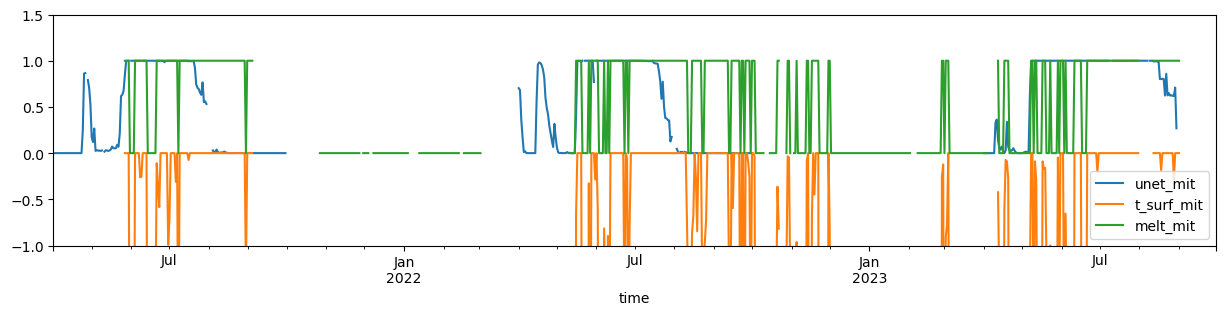

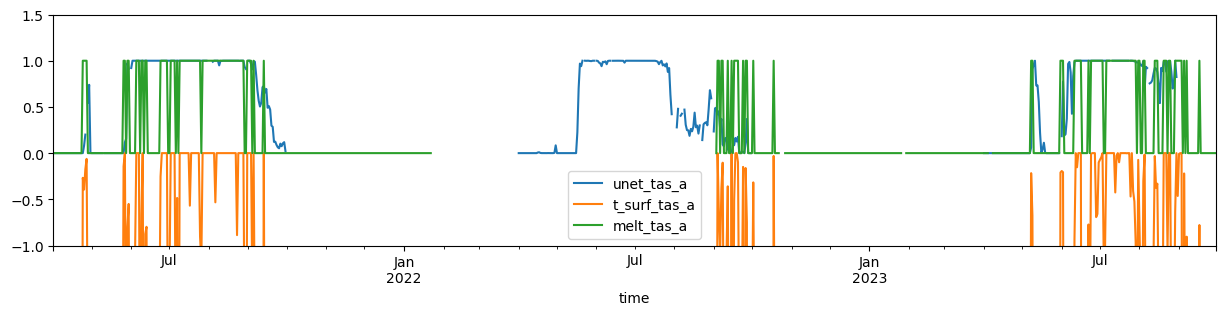

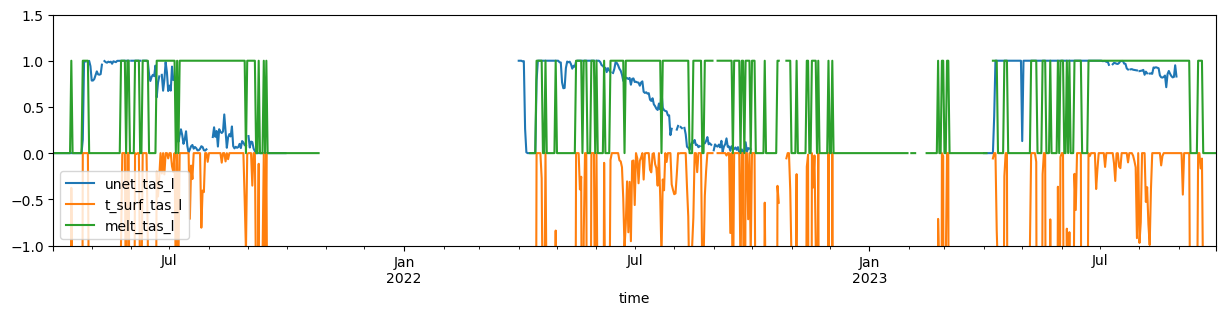

In [41]:
for station in ['mit', 'tas_a', 'tas_l']:
    vars_station = [var for var in ds.data_vars if station in var]
    ds_station = ds[vars_station]
    ds_station.sel(time=slice(f'{2021}-04-01T00:00:00',f'{2023}-09-30T21:00:00')).to_pandas().plot(ylim=(-1,1.5), figsize=(15,3))

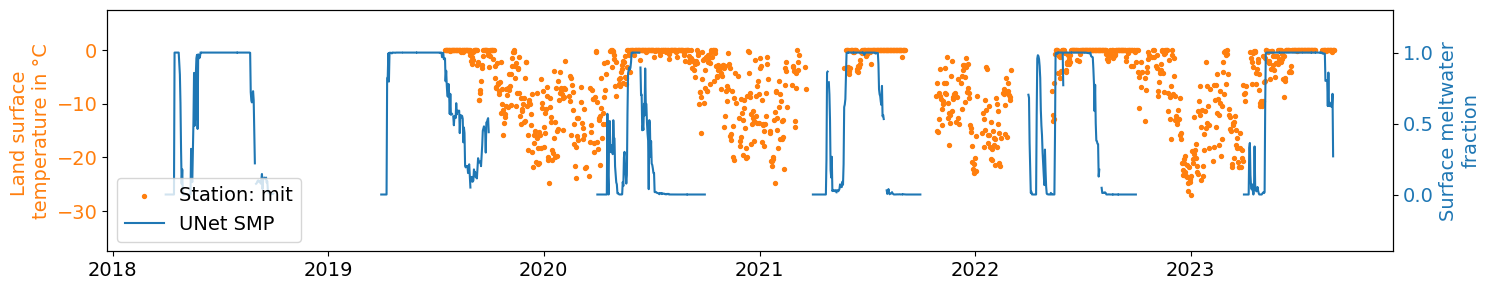

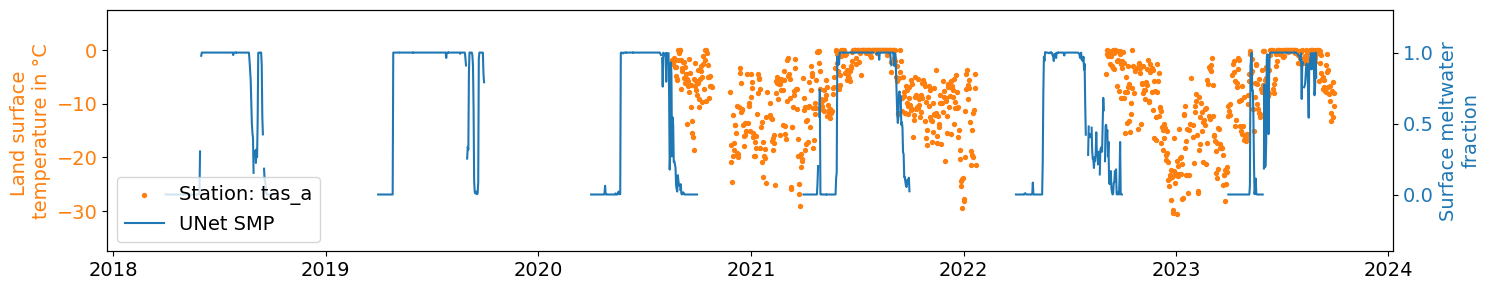

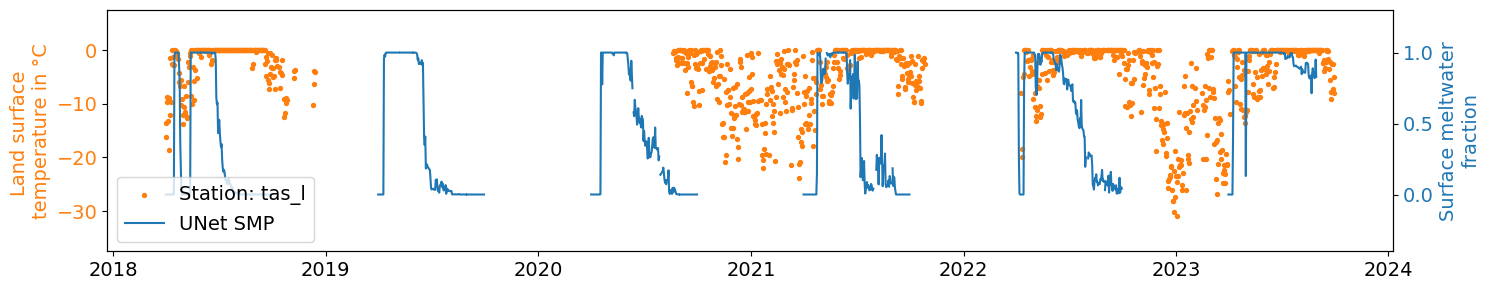

In [42]:
FS = 14  # base fontsize

for station in ['mit', 'tas_a', 'tas_l']:
    df_sel = ds.sel(time=slice('2018-04-01T00:00:00', '2023-09-30T21:00:00')).to_pandas()

    fig, ax1 = plt.subplots(figsize=(15, 3))

    # t_surf on secondary axis; map [-30,0] onto the same [-0.5,1.5] fractional range
    t_min, t_max = -30, 0
    ax1.scatter(df_sel.index, df_sel[f't_surf_{station}'], color='tab:orange', s=8, label=f'Station: {station}')
    ax1.set_ylim(t_min - 0.25 * (t_max - t_min), t_max + 0.25 * (t_max - t_min))  # match -0.5/1.5 fractions
    ax1.set_ylabel(f'Land surface \ntemperature in °C', color='tab:orange', fontsize=FS)
    ax1.tick_params(axis='y', labelcolor='tab:orange', labelsize=FS)
    ax1.tick_params(axis='x', labelsize=FS)

    # unet on primary axis, fixed range
    ax2 = ax1.twinx()
    ax2.plot(df_sel.index, df_sel[f'unet_{station}'], color='tab:blue', label=f'UNet SMP')
    ax2.set_ylim(-0.4, 1.3)
    ax2.set_ylabel(f'Surface meltwater\nfraction', color='tab:blue', fontsize=FS)
    ax2.tick_params(axis='y', labelcolor='tab:blue', labelsize=FS)

    # merge handles from both axes into one legend inside the frame
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, loc='lower left', fontsize=FS)

    fig.tight_layout()
    plt.show()

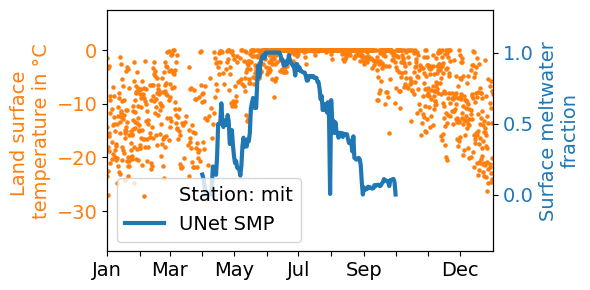

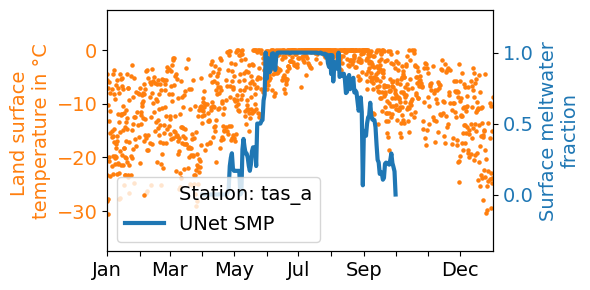

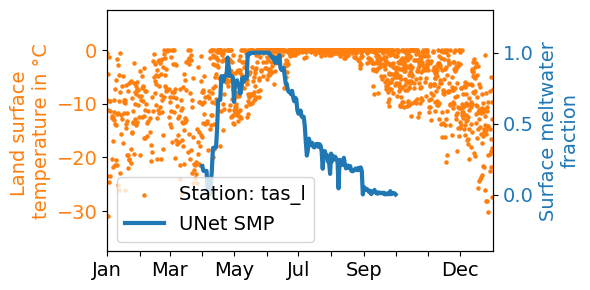

In [43]:
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

FS = 14  # base fontsize

# day-of-year for the 1st of each month (non-leap year), + month labels
month_starts = pd.date_range('2019-01-01', '2019-12-01', freq='MS').dayofyear
month_labels = ['Jan','','Mar','','May','','Jul','','Sep','','','Dec']

# Remove 2017 from analysis
df_sel = ds.sel(time=slice('2018-04-01T00:00:00', '2023-09-30T21:00:00'))

for station in ['mit', 'tas_a', 'tas_l']:
    fig, ax1 = plt.subplots(figsize=(6, 3))

    # t_surf: all observations across all years as scatter, mapped onto day-of-year
    t_min, t_max = -30, 0
    t_surf = ds[f't_surf_{station}']
    ax1.scatter(t_surf['time'].dt.dayofyear, t_surf, color='tab:orange', s=5, label=f'Station: {station}')
    ax1.set_ylim(t_min - 0.25 * (t_max - t_min), t_max + 0.25 * (t_max - t_min))  # match -0.5/1.5 fractions
    ax1.set_ylabel(f'Land surface \ntemperature in °C', color='tab:orange', fontsize=FS)
    ax1.tick_params(axis='y', labelcolor='tab:orange', labelsize=FS)
    ax1.tick_params(axis='x', labelsize=FS)   # month labels live on ax1's shared x-axis
    
    # unet: average seasonal cycle across all years by day-of-year (skips nans)
    ax2 = ax1.twinx()
    unet_doy = df_sel[f'unet_{station}'].groupby('time.dayofyear').mean()
    ax2.plot(unet_doy['dayofyear'], unet_doy, color='tab:blue', label=f'UNet SMP', linewidth=3)
    ax2.set_ylim(-0.4, 1.3)
    ax2.set_xlim(1, 366)
    ax2.set_xticks(month_starts)          # ticks at the 1st of each month
    ax2.set_xticklabels(month_labels)     # labeled by month
    ax2.set_xlabel('month', fontsize=FS)
    ax2.set_ylabel(f'Surface meltwater\nfraction', color='tab:blue', fontsize=FS)
    ax2.tick_params(axis='y', labelcolor='tab:blue', labelsize=FS)
    ax2.tick_params(axis='x', labelsize=FS+16)   # x ticks live on ax2

    # merge handles from both axes into one legend inside the frame
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax2.legend(h1 + h2, l1 + l2, loc='lower left', fontsize=FS)

    fig.tight_layout()
    plt.show()

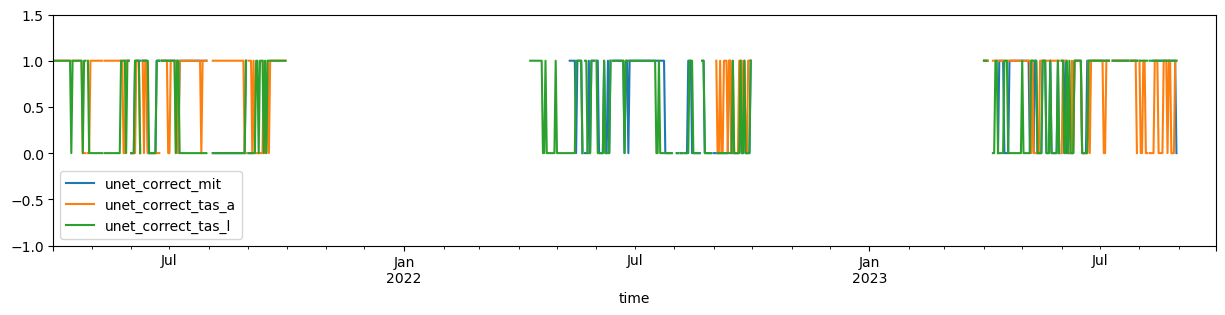

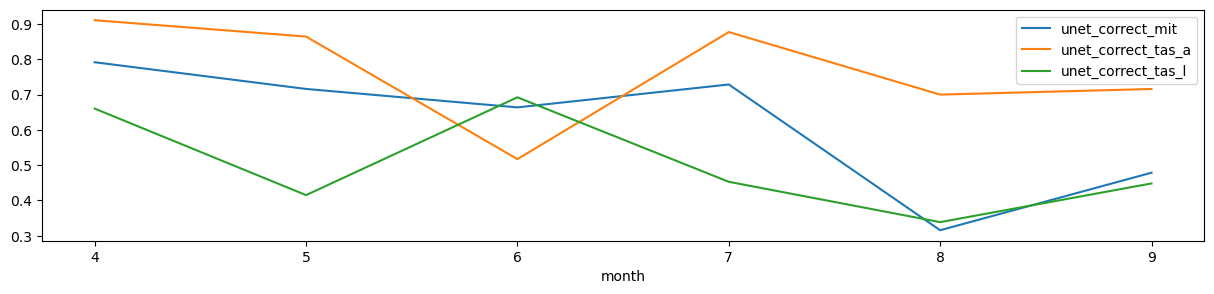

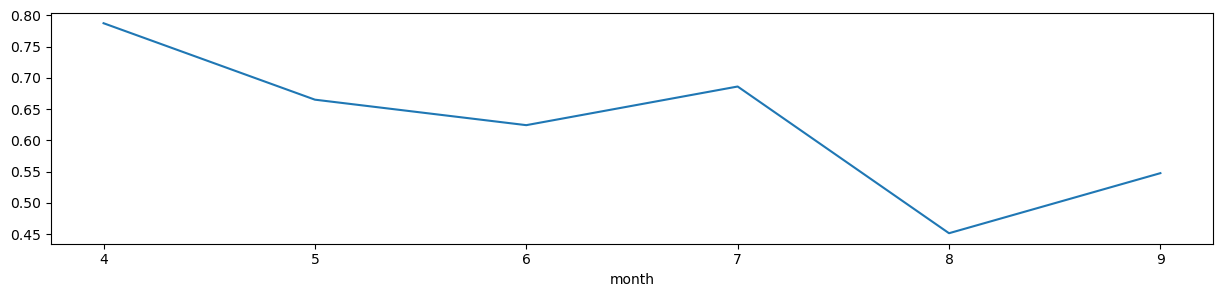

In [44]:
melt_thold = 0.5  # your threshold

def correct(mit, unet_raw):
    unet = xr.where(unet_raw >= melt_thold, 1.0, 0.0).where(~np.isnan(unet_raw))
    return xr.where(mit == unet, 1.0, 0.0).where(~np.isnan(mit) & ~np.isnan(unet_raw))

ds_correct = xr.Dataset({
    f'unet_correct_{station_name}': correct(ds[f'melt_{station_name}'], ds[f'unet_{station_name}'])
    for station_name in station_names
})
ds_correct.sel(time=slice(f'{2021}-04-01T00:00:00',f'{2023}-09-30T21:00:00')).to_pandas().plot(ylim=(-1,1.5), figsize=(15,3))
ds_correct_monthly = ds_correct.groupby('time.month').mean()
ds_correct_monthly.to_pandas().plot(figsize=(15,3))
ds_correct_monthly.to_array().mean('variable').plot(figsize=(15,3))

### Compute metrics wrt station

In [9]:
# Compute accuracy and f1-score
from sklearn.metrics import accuracy_score, f1_score

# Find best threshold per station
thresholds = [0.05] # np.arange(0.05, 1.05, 0.05)
stations = ['mit', 'tas_a', 'tas_l']

results = {}
for station_name in stations:
    obs = ds[f'melt_{station_name}'].values
    best_thold, best_f1, best_acc, best_n = 0.05, -1, np.nan, 0

    for melt_thold in thresholds:
        pred = xr.where(ds[f'unet_{station_name}'] >= melt_thold, 1.0, 0.0).where(~np.isnan(ds[f'unet_{station_name}'])).values
        valid = ~np.isnan(obs) & ~np.isnan(pred)
        obs_valid, pred_valid = obs[valid].astype(int), pred[valid].astype(int)
        if len(obs_valid) == 0: continue
        f1 = f1_score(obs_valid, pred_valid, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thold, best_acc, best_n = f1, melt_thold, accuracy_score(obs_valid, pred_valid), int(valid.sum())

    results[station_name] = {"n_valid": best_n, "accuracy": round(best_acc, 4), "f1": round(best_f1, 4), "threshold": round(best_thold, 2)}
    ds[f'melt_unet_{station_name}'] = xr.where(ds[f'unet_{station_name}'] >= best_thold, 1.0, 0.0).where(~np.isnan(ds[f'unet_{station_name}']))

# Compute mean accuracy and F1 with equal weights per station
valid_results = [r for r in results.values() if not np.isnan(r['accuracy'])]
mean_acc = np.mean([r['accuracy'] for r in valid_results])
mean_f1  = np.mean([r['f1'] for r in valid_results])

print(f"{'station_name':<10} {'N valid':>8} {'Accuracy':>10} {'F1 Score':>10} {'Threshold':>10}")
print("-" * 52)
for station_name, r in results.items():
    print(f"{station_name:<10} {r['n_valid']:>8} {r['accuracy']:>10.4f} {r['f1']:>10.4f} {r['threshold']:>10.2f}")
print(f"{'mean':<10} {'':>8} {mean_acc:>10.4f} {mean_f1:>10.4f}")


station_name  N valid   Accuracy   F1 Score  Threshold
----------------------------------------------------
mit             601     0.6123     0.7047       0.05
tas_a           388     0.6830     0.6772       0.05
tas_l           699     0.6094     0.6950       0.05
mean                    0.6349     0.6923


In [ ]:
"""
For LST threshold:
For Threshold of 0.5:
station_name  N valid   Accuracy   F1 Score
------------------------------------------
mit             601     0.5707     0.6325
tas_a           388     0.7345     0.6869
tas_l           699     0.4621     0.5117

Threshold with best F1-score giving each station equal weight: 0.05
station_name  N valid   Accuracy   F1 Score
------------------------------------------
mit             601     0.6123     0.7047
tas_a           388     0.6830     0.6772
tas_l           699     0.6094     0.6950
mean                    0.6349     0.6923

Threshold with best F1-score for each station
station_name  N valid   Accuracy   F1 Score  Threshold
----------------------------------------------------
mit             601     0.6223     0.7079       0.10
tas_a           388     0.7887     0.7230       0.90
tas_l           699     0.6094     0.6950       0.05
"""

"""
For air temperature threshold:
For Threshold of 0.5:
station_name  N valid   Accuracy   F1 Score  Threshold
----------------------------------------------------
mit             902     0.5976     0.6630       0.50
tas_a           732     0.7473     0.7483       0.50
tas_l           989     0.4328     0.4858       0.50
mean                    0.5926     0.6324

Threshold with best F1-score giving each station equal weight: 0.05
station_name  N valid   Accuracy   F1 Score  Threshold
----------------------------------------------------
mit             902     0.6242     0.7168       0.05
tas_a           732     0.7227     0.7472       0.05
tas_l           989     0.6006     0.6926       0.05
mean                    0.6492     0.7189

Threshold with best F1-score for each station
station_name  N valid   Accuracy   F1 Score  Threshold
----------------------------------------------------
mit             902     0.6242     0.7168       0.05
tas_a           732     0.7377     0.7519       0.15
tas_l           989     0.6006     0.6926       0.05
mean                    0.6542     0.7204
"""

'\nFor air temperature threshold:\nFor Threshold of 0.5:\nstation_name  N valid   Accuracy   F1 Score  Threshold\n----------------------------------------------------\nmit             902     0.5976     0.6630       0.50\ntas_a           732     0.7473     0.7483       0.50\ntas_l           989     0.4328     0.4858       0.50\nmean                    0.5926     0.6324\n\nThreshold with best F1-score giving each station equal weight: 0.05\nstation_name  N valid   Accuracy   F1 Score  Threshold\n----------------------------------------------------\nmit             902     0.6242     0.7168       0.05\ntas_a           732     0.7227     0.7472       0.05\ntas_l           989     0.6006     0.6926       0.05\nmean                    0.6492     0.7189\n\nThreshold with best F1-score for each station\nstation_name  N valid   Accuracy   F1 Score  Threshold\n----------------------------------------------------\nmit             902     0.6242     0.7168       0.05\ntas_a           732     0.73

### Scripts to double-check the Matlab analysis for evaluating model predictions on station data

(363, 1133) 46.267864


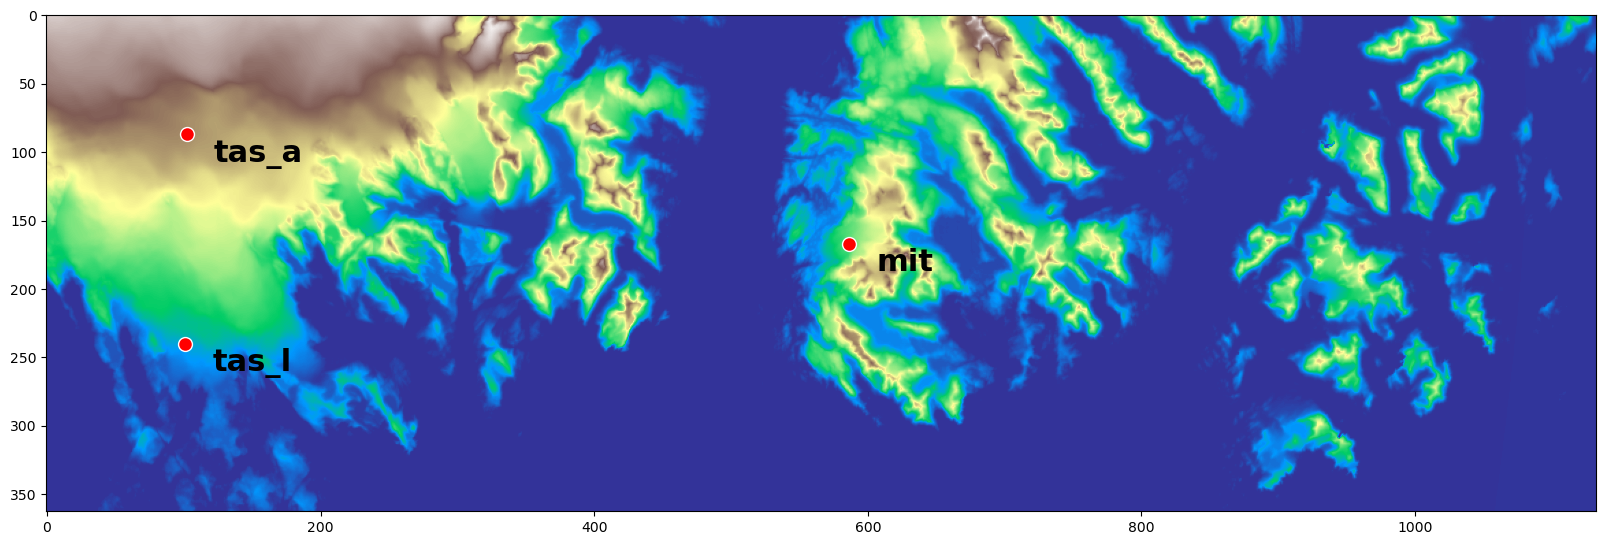

In [126]:
# Plot position of weather stations

offset_top = 1900 # 1950, Offset from top of image in px
offset_bottom = 600 # 700
offset_left = 400 # 500 Offset from left of image in px
offset_right = 100 # 600

data_root = '/Users/bjoern/data/hrmelt/meltwaterbench/'
path_dem = 'raw/Helheim_data/reprojected_100m/GrIMP_DEM/dem_100m.tif'
ds = gdal.Open(data_root + path_dem)
img_size = [ds.RasterYSize, ds.RasterXSize] # height, width

# Read the cropped area into memory using GDAL
offsets = [int(offset_top), int(offset_left)]
tile_size = [int(img_size[0] - offset_top - offset_bottom), int(img_size[1] - offset_left - offset_right)] # height, width
dem = ds.GetRasterBand(1).ReadAsArray(
    offsets[1], offsets[0], tile_size[1], tile_size[0])
del ds

plt.figure(figsize=(20,20))
plt.imshow(dem, cmap = 'terrain')
for station_name in coords_stations.keys(): 
    coords = coords_stations[station_name].copy()
    coords = [coords[0] - offset_top, coords[1] - offset_left]
    plt.plot(coords[1], coords[0], 'ro', markersize=10, markeredgecolor='white')  # Red dot with white edge
    plt.annotate(station_name, xy=(coords[1], coords[0]), xytext=(coords[1] + 20, coords[0] + 20), color='black', fontsize=22, weight='bold')

dem_sea_level_elevation = dem.min()
print(dem.shape, dem.min())

/Users/bjoern/data/hrmelt/meltwaterbench/interim/runs/unet_smp/data_v1_4/deploy/2018_09_30.tif
(363, 1133)


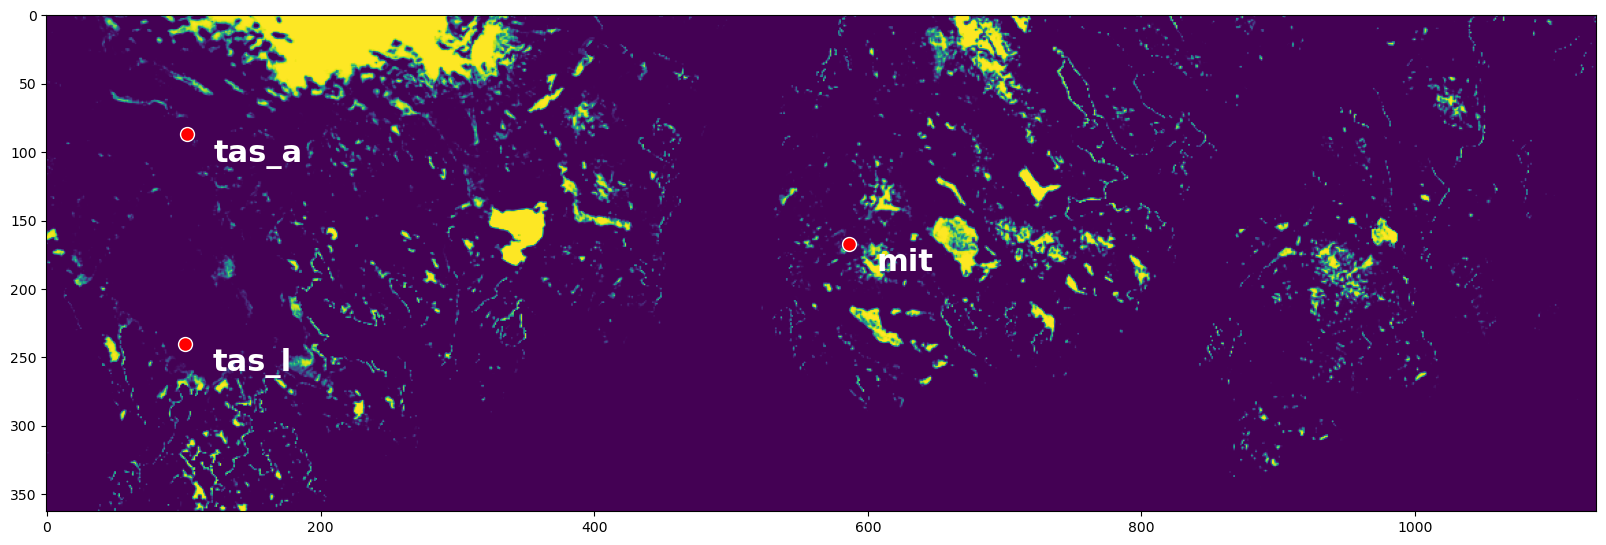

In [ ]:
path_unet = paths_unet_smp[242] # 2018-06-05
path_unet = paths_unet_smp[356] # 2018-09-30
print(path_unet)

# Open geotiff metadata
ds = gdal.Open(str(path_unet))
assert img_size == [ds.RasterYSize, ds.RasterXSize] # height, width

preds_unet = ds.GetRasterBand(1).ReadAsArray(
    offsets[1], offsets[0], tile_size[1], tile_size[0])
del ds

plt.figure(figsize=(20,20))
plt.imshow(preds_unet, cmap = 'viridis')
for station_name in coords_stations.keys(): 
    coords = coords_stations[station_name].copy()
    coords = [coords[0] - offset_top, coords[1] - offset_left]
    plt.plot(coords[1], coords[0], 'ro', markersize=10, markeredgecolor='white')  # Red dot with white edge
    plt.annotate(station_name, xy=(coords[1], coords[0]), xytext=(coords[1] + 20, coords[0] + 20), color='white', fontsize=22, weight='bold')

print(preds_unet.shape)

In [48]:
# Verify station position
# Open geotiff metadata
ds = gdal.Open(data_root + path_dem)
img_size = [ds.RasterYSize, ds.RasterXSize] # height, width

station_name = 'mit'
coords = coords_stations[station_name].copy()

# Read the cropped area into memory using GDAL
tile_size = [1,1] # height, width of area of interest surrounding weather station
dem = ds.GetRasterBand(1).ReadAsArray(
    int(coords[1]), int(coords[0]), tile_size[1], tile_size[0])
del ds

print('DEM at station; without accounting for Earth ellipsoid in m: ', dem)
print('DEM at station; after accounting for Earth ellipsoid in m: ', dem - dem_sea_level_elevation)
#plt.figure() # figsize=(20,20)
#plt.imshow(dem, cmap = 'terrain')
#coords_tile = [coords[0] - offset_top, coords[1] - offset_left]
#plt.plot(coords_tile[1], coords_tile[0], 'ro', markersize=10, markeredgecolor='white')  # Red dot with white edge

DEM at station; without accounting for Earth ellipsoid in m:  [[491.13104]]
DEM at station; after accounting for Earth ellipsoid in m:  [[445.02603]]


In [49]:
# Load SAR-derived targets

### Repeat with previous station data

In [184]:
# Load station data from .csv
path_station = '/home/gridsan/lutjens/EarthIntelligence_shared/datasets/hrmelt/raw/promice_station_data/day/MIT_day.csv'
df_station = pd.read_csv(path_station)
df_station.set_index('time', inplace=True)
df_station.index = pd.to_datetime(df_station.index)
df['t_surf'] = df_station['t_surf']
df['albedo'] = df_station['albedo']

(-1.2, 1.2)

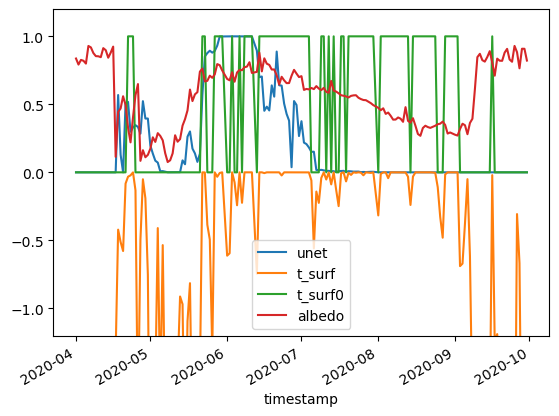

In [ ]:
# Apply melt threshold to station data
df['t_surf0'] = np.where(df['t_surf'] > -0.05, 1., 0.)
# Filter for April 2018 only
df_study_period = df['2020-04-01':'2020-09-30']
axs = df_study_period.plot()
axs.set_ylim((-1.2,1.2))

In [161]:
path_station = '/home/gridsan/lutjens/EarthIntelligence_shared/datasets/hrmelt/raw/promice_station_data/hour/MIT_hour.csv'

In [121]:
df['t_surf0'] 

timestamp
2020-04-01    False
2020-04-02    False
2020-04-03    False
2020-04-04    False
2020-04-05    False
              ...  
2020-09-26    False
2020-09-27    False
2020-09-28    False
2020-09-29    False
2020-09-30    False
Name: t_surf0, Length: 178, dtype: bool

### Continue position verification

(100, 100)


(48.38013, 1122.7623)

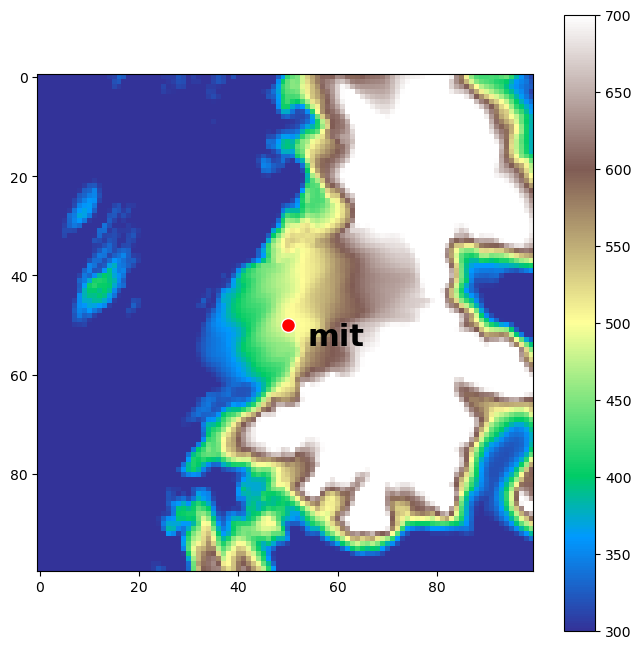

In [163]:
# Plot position of weather stations
from osgeo import gdal
import matplotlib.pyplot as plt
from pathlib import Path

data_root = '/home/gridsan/lutjens/EarthIntelligence_shared/datasets/hrmelt/'
path_dem = 'raw/Helheim_data/reprojected_100m/GrIMP_DEM/dem_100m.tif'

# Open geotiff metadata
ds = gdal.Open(data_root + path_dem)
img_size = [ds.RasterYSize, ds.RasterXSize] # height, width

offset_top = coords_stations['mit'][0] - 50 # 1950, Offset from top of image in px
offset_bottom = img_size[0] - coords_stations['mit'][0] - 50 # 700
offset_left = coords_stations['mit'][1] - 50 # 500 Offset from left of image in px
offset_right = img_size[1] - coords_stations['mit'][1] - 50

# Read the cropped area into memory using GDAL
offsets = [int(offset_top), int(offset_left)]
tile_size = [int(img_size[0] - offset_top - offset_bottom), int(img_size[1] - offset_left - offset_right)] # height, width
dem = ds.GetRasterBand(1).ReadAsArray(
    offsets[1], offsets[0], tile_size[1], tile_size[0])
del ds

plt.figure(figsize=(8,8))
plt.imshow(dem, cmap = 'terrain', vmin=300, vmax=700)
station_name = 'mit'
coords = coords_stations[station_name].copy()
coords = [coords[0] - offset_top, coords[1] - offset_left]
plt.plot(coords[1], coords[0], 'ro', markersize=10, markeredgecolor='white')  # Red dot with white edge
plt.annotate(station_name, xy=(coords[1], coords[0]), xytext=(coords[1] + 4, coords[0] + 4), color='black', fontsize=22, weight='bold')
plt.colorbar()

print(dem.shape)
dem.min(), dem.max()

/home/gridsan/lutjens/EarthIntelligence_shared/datasets/hrmelt/interim/runs/unet_smp/data_v1_4/deploy/2020_08_28.tif


Text(54, 54, 'mit')

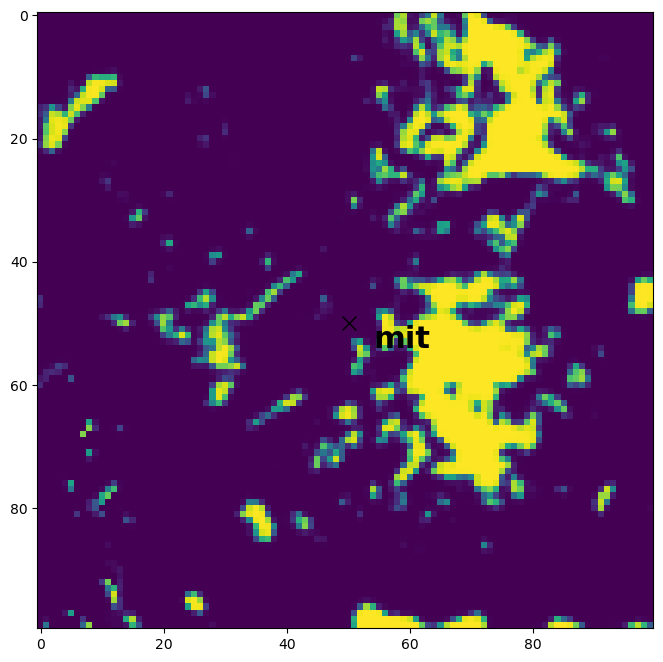

In [192]:
path_deploy_unet_smp = '/home/gridsan/lutjens/EarthIntelligence_shared/datasets/hrmelt/interim/runs/unet_smp/data_v1_4/deploy/'
paths_unet_smp = sorted(list(Path(path_deploy_unet_smp).glob("*.tif")))
path_unet = paths_unet_smp[680]
print(path_unet)
# Open geotiff metadata
ds = gdal.Open(str(path_unet))
assert img_size == [ds.RasterYSize, ds.RasterXSize] # height, width
preds_unet = ds.GetRasterBand(1).ReadAsArray(
    offsets[1], offsets[0], tile_size[1], tile_size[0])
del ds
plt.figure(figsize=(8,8))
plt.imshow(preds_unet, cmap = 'viridis')
station_name = 'mit'
coords = coords_stations[station_name].copy()
coords = [coords[0] - offset_top, coords[1] - offset_left]
plt.plot(coords[1], coords[0], 'x', markersize=10, markeredgecolor='black')
plt.annotate(station_name, xy=(coords[1], coords[0]), xytext=(coords[1] + 4, coords[0] + 4), color='black', fontsize=22, weight='bold')

(100, 100)


(-1.0, 1.0)

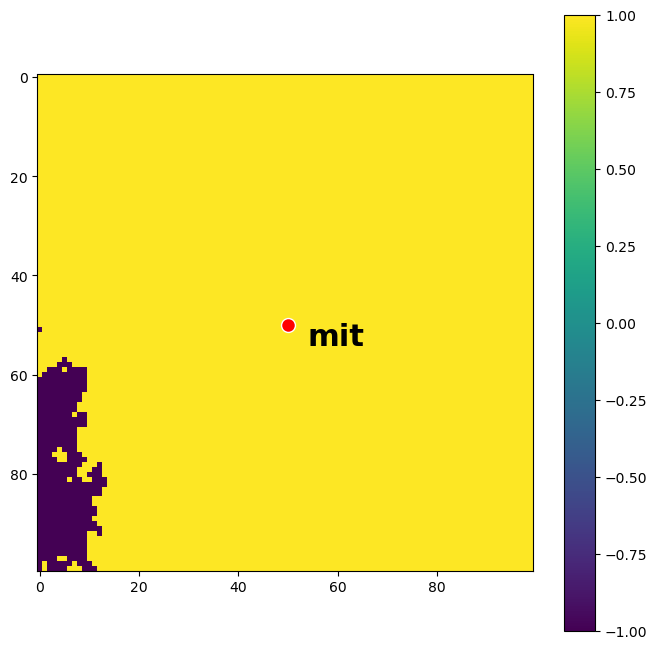

In [198]:

data_root = '/home/gridsan/lutjens/EarthIntelligence_shared/datasets/hrmelt/'
path_landmask = 'raw/Helheim_data/reprojected_100m/GIMP_Mask/landMask_100m.tif'

# Open geotiff metadata
ds = gdal.Open(data_root + path_landmask)
img_size = [ds.RasterYSize, ds.RasterXSize] # height, width

offset_top = coords_stations['mit'][0] - 50 # 1950, Offset from top of image in px
offset_bottom = img_size[0] - coords_stations['mit'][0] - 50 # 700
offset_left = coords_stations['mit'][1] - 50 # 500 Offset from left of image in px
offset_right = img_size[1] - coords_stations['mit'][1] - 50

# Read the cropped area into memory using GDAL
offsets = [int(offset_top), int(offset_left)]
tile_size = [int(img_size[0] - offset_top - offset_bottom), int(img_size[1] - offset_left - offset_right)] # height, width
landmask = ds.GetRasterBand(1).ReadAsArray(
    offsets[1], offsets[0], tile_size[1], tile_size[0])
del ds

plt.figure(figsize=(8,8))
plt.imshow(landmask)
station_name = 'mit'
coords = coords_stations[station_name].copy()
coords = [coords[0] - offset_top, coords[1] - offset_left]
plt.plot(coords[1], coords[0], 'ro', markersize=10, markeredgecolor='white')  # Red dot with white edge
plt.annotate(station_name, xy=(coords[1], coords[0]), xytext=(coords[1] + 4, coords[0] + 4), color='black', fontsize=22, weight='bold')
plt.colorbar()

print(landmask.shape)
landmask.min(), landmask.max()